# Titanic dataset

In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

In [5]:
# lấy đường dẫn đến file dữ liệu
# Sử dụng đường dẫn tương đối (hoạt động trong Jupyter)
FILE_NAME = os.path.join("..", "data", "titanic", "Titanic-Dataset.csv")
# đọc dữ liệu từ file csv
df = pd.read_csv(FILE_NAME)
# hiển thị 5 dòng đầu tiên của dữ liệu
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Survival rate tổng thể
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [11]:
# Giới tính ảnh hưởng thế nào?
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
# Hạng vé (giàu vs nghèo)
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [13]:
# Tuổi tác động ra sao?
df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5644\1628187156.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()


Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

### Xử lí dử liệu thiếu

In [17]:
# Age có nhiều giá trị thiếu, ta sẽ điền vào bằng giá trị trung vị (median)
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
# Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [19]:
# Cabin → bỏ
df = df.drop(columns=['Cabin'])

In [20]:
# Feature Engineering
# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [21]:
# Title từ tên
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [22]:
# Encode dữ liệu (chuẩn bị cho ML)
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [23]:
# Model đơn giản (baseline)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.8324022346368715

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[100   7]
 [ 23  49]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       107
           1       0.88      0.68      0.77        72

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.83      0.83       179



In [25]:
# Feature nào quan trọng?

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)

print(feature_importance)

           feature      coef
16    Title_Master  1.709689
21       Title_Mrs  0.621658
15     Title_Major  0.337158
24       Title_Sir  0.328951
17      Title_Miss  0.223243
14      Title_Lady  0.126393
18      Title_Mlle  0.091586
10  Title_Countess  0.088860
19       Title_Mme  0.049101
11       Title_Don  0.000000
22        Title_Ms  0.000000
4             Fare -0.000618
3            Parch -0.016098
1              Age -0.030331
7       Embarked_Q -0.086149
9        Title_Col -0.127258
5       FamilySize -0.210023
2            SibSp -0.215028
8       Embarked_S -0.398770
12        Title_Dr -0.506657
13  Title_Jonkheer -0.568333
23       Title_Rev -1.025726
0           Pclass -1.168367
20        Title_Mr -1.327564
6         Sex_male -1.397210


In [26]:
# Cải thiện model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8268156424581006

In [32]:
# Feature engineering nâng cao
# Age theo nhóm Pclass
df = pd.read_csv(FILE_NAME)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [33]:
# Family size grouping

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [34]:
# Fare log transform
df['Fare'] = np.log1p(df['Fare'])

In [35]:
# Cross Validation (đừng phụ thuộc 1 lần split)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.8036155922415416


In [36]:
# Tuning model
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


In [37]:
# Train lại model với best params

model = RandomForestClassifier(
    max_depth=5,
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Đánh giá lại model

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       107
           1       0.85      0.71      0.77        72

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [39]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8398876404494382
0.8324022346368715


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# style cho đẹp
sns.set(style="whitegrid")

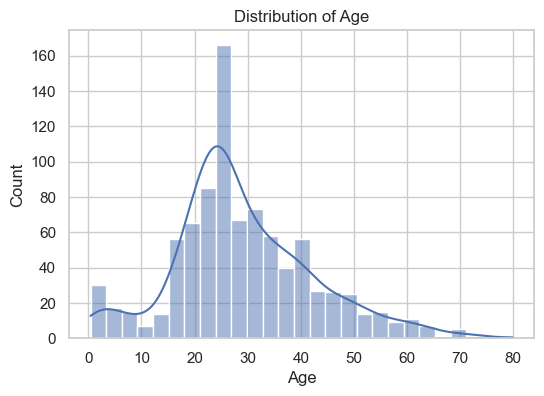

In [41]:
# Histogram của Age

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

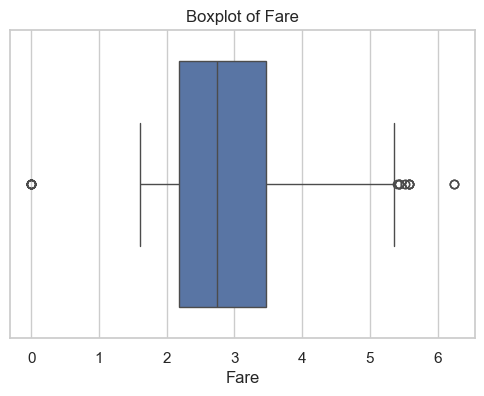

In [42]:
# Boxplot của Fare 
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])

plt.title("Boxplot of Fare")

plt.show()

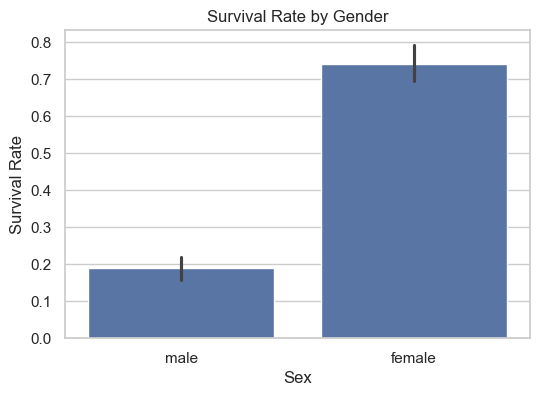

In [44]:
# Bar chart: Survival theo giới tính
df = pd.read_csv(FILE_NAME)
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")

plt.show()

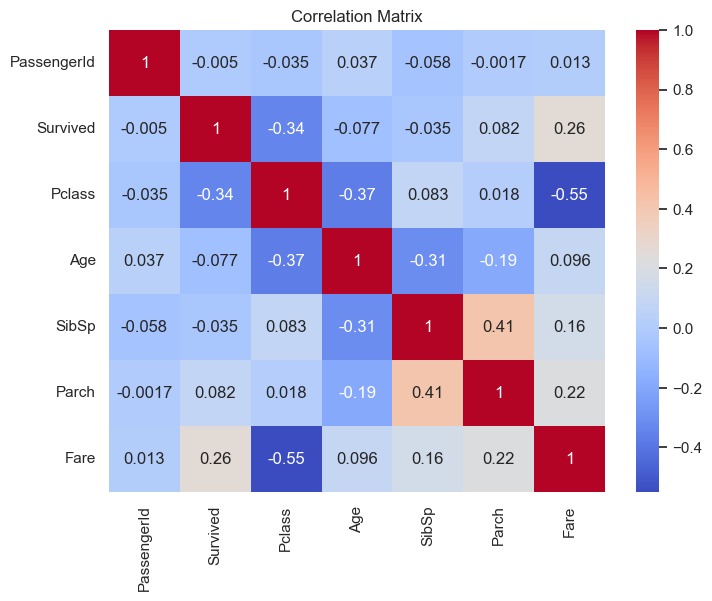

In [45]:
# Heatmap correlation

plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()